# Notebook 1: Replication of Dai, Kou, Qian & Wan (2019)
## Non-Concave Utility Maximization — Finite Difference Scheme

**Paper**: "Non-Concave Utility Maximization without the Concavification Principle"
*Min Dai, Steven Kou, Shuaijie Qian, Xiangwei Wan (2019)*

### What this notebook does
1. Implements the monotone finite-difference scheme from Appendix B of the paper
2. Replicates Figures 3, 5 (goal-reaching) and Figures 6, 8 (aspiration utility)
3. Replicates Table 3 (time to beat benchmarks)
4. Benchmarks execution time and performs a convergence analysis

### Market model
- Risky stock: $dS_t = \mu S_t\,dt + \sigma S_t\,dB_t$
- Forward wealth: $dW_t = W_t \pi_t(\eta\,dt + \sigma\,dB_t)$, $\eta = \mu - r$
- Portfolio constraint: $\pi_t \in [d, u]$, liquidation floor $W_t \ge B$

### HJB equation
$$\frac{\partial V}{\partial t} + \sup_{d \le \pi \le u}\left\{\frac{1}{2}\pi^2 w^2\sigma^2 \frac{\partial^2 V}{\partial w^2} + \pi w\eta\frac{\partial V}{\partial w}\right\} = 0$$


In [18]:
import numpy as np
import matplotlib.pyplot as plt
import time
from scipy.stats import norm

plt.rcParams.update({'font.size': 12, 'figure.dpi': 100,
                     'axes.grid': True, 'grid.alpha': 0.3})
print("Imports OK — NumPy", np.__version__)


Imports OK — NumPy 1.26.2


## 1. Finite Difference Solver (Appendix B)

The scheme discretises $[0,T]\times[B,A]$ with steps $\Delta t$ and $\Delta w$.
At each backward time step we solve a nonlinear equation via **policy iteration**:
freeze $\pi_i^{n,k}$, solve the resulting tridiagonal linear system for $V_i^{n,k+1}$,
then recompute the optimal $\pi$. Repeat until convergence.

The first-order upwind difference (Eq. 35) is:
$$\Delta V_i^n(\pi) = \begin{cases}
(V_{i+1}^n - V_{i-1}^n)/2 & |\pi| > \pi_i \\
V_{i+1}^n - V_i^n & |\pi| < \pi_i,\ \pi\eta > 0 \\
V_i^n - V_{i-1}^n & |\pi| < \pi_i,\ \pi\eta < 0
\end{cases}$$
where $\pi_i = |\eta|\Delta w / (\sigma^2 w_i)$.


In [19]:
class FDSolver:
    """
    Monotone finite-difference solver for the HJB equation (Eq. 17) from Dai et al. (2019).

    Parameters
    ----------
    mu, r, sigma : float   -- market parameters
    T            : float   -- investment horizon
    B, A         : float   -- wealth grid lower/upper bound
    d, u         : float   -- portfolio weight constraints [d, u]
    Nw, Nt       : int     -- grid points in wealth and time
    utility_fn   : callable -- terminal / boundary utility U(w)
    """

    def __init__(self, mu=0.15, r=0.07, sigma=0.3, T=1.0,
                 B=0.0, A=3.0, d=0.0, u=1.0,
                 Nw=200, Nt=200, utility_fn=None):
        self.mu, self.r, self.sigma = mu, r, sigma
        self.eta = mu - r
        self.T, self.B, self.A = T, B, A
        self.d, self.u = d, u
        self.Nw, self.Nt = Nw, Nt
        self.utility_fn = utility_fn if utility_fn else lambda w: (w >= 1.0).astype(float)

        # Grids
        self.w = np.linspace(B, A, Nw + 1)        # wealth grid  [0..Nw]
        self.dw = (A - B) / Nw
        self.dt = T / Nt

        # Threshold for central vs upwind differencing (Eq. 35)
        self.pi_thresh = np.where(self.w > 0,
                                  abs(self.eta) * self.dw / (sigma**2 * self.w + 1e-12),
                                  np.inf)

    # ── inner maximisation ────────────────────────────────────────────────────
    def _optimal_pi(self, V, i):
        """Compute optimal π at interior node i given current V array.
        Three-case logic handles both concave (Vww<0) and convex (Vww>0) Hamiltonians.
        """
        if i == 0 or i == len(V) - 1:
            return self.d
        w_i  = self.w[i]
        dw   = self.dw
        sig2 = self.sigma**2
        eta  = self.eta
        Vww  = (V[i+1] - 2*V[i] + V[i-1]) / dw**2
        Vw   = (V[i+1] - V[i-1]) / (2 * dw)

        if Vww < -1e-12:
            # Concave: unique interior maximiser, clip to [d, u]
            pi_opt = -w_i * eta * Vw / (w_i**2 * sig2 * Vww)
            return float(np.clip(pi_opt, self.d, self.u))
        elif Vww > 1e-12:
            # Convex: maximum is at one of the constraint boundaries
            f_d = 0.5 * self.d**2 * w_i**2 * sig2 * Vww + self.d * w_i * eta * Vw
            f_u = 0.5 * self.u**2 * w_i**2 * sig2 * Vww + self.u * w_i * eta * Vw
            return float(self.u if f_u >= f_d else self.d)
        else:
            # Linear in π: maximiser at appropriate boundary
            return float(self.u if eta * Vw > 0 else self.d)

    def _objective(self, V, i, pi):
        """Value of the HJB objective for a given π at grid point i."""
        w_i = self.w[i]
        dw  = self.dw
        # Second derivative (central differencing)
        if i == 0 or i == len(V) - 1:
            return -1e10
        V_ww = (V[i+1] - 2*V[i] + V[i-1]) / dw**2

        # First derivative (upwind, Eq. 35)
        pi_thresh_i = self.pi_thresh[i]
        if abs(pi) >= pi_thresh_i:
            V_w = (V[i+1] - V[i-1]) / (2 * dw)   # central
        elif pi * self.eta > 0:
            V_w = (V[i+1] - V[i])   / dw           # forward
        else:
            V_w = (V[i]   - V[i-1]) / dw           # backward

        return 0.5 * pi**2 * w_i**2 * self.sigma**2 * V_ww + pi * w_i * self.eta * V_w

    # ── tridiagonal solver (Thomas algorithm) ─────────────────────────────────
    @staticmethod
    def _thomas(a, b, c, d_rhs):
        """Solve tridiagonal system. a=sub, b=main, c=super diagonals."""
        n = len(b)
        c2 = np.zeros(n); d2 = np.zeros(n)
        x  = np.zeros(n)
        c2[0] = c[0] / b[0]
        d2[0] = d_rhs[0] / b[0]
        for k in range(1, n):
            denom = b[k] - a[k] * c2[k-1]
            c2[k] = c[k] / denom if k < n-1 else 0.0
            d2[k] = (d_rhs[k] - a[k] * d2[k-1]) / denom
        x[-1] = d2[-1]
        for k in range(n-2, -1, -1):
            x[k] = d2[k] - c2[k] * x[k+1]
        return x

    # ── full backward solve ───────────────────────────────────────────────────
    def solve(self, max_policy_iter=30, tol=1e-8):
        """
        Solve the HJB backward in time using policy iteration.

        Returns
        -------
        V   : (Nt+1, Nw+1) value function array
        Pi  : (Nt+1, Nw+1) optimal portfolio weight array
        """
        Nw, Nt = self.Nw, self.Nt
        V  = np.zeros((Nt + 1, Nw + 1))
        Pi = np.zeros((Nt + 1, Nw + 1))

        # Terminal condition V(T, w) = U(w)
        V[Nt, :] = self.utility_fn(self.w)
        Pi[Nt, :] = 0.0

        # Boundary: V(t, B) = U(B), V(t, A) = U(A)
        UB = float(self.utility_fn(np.array([self.B])).flat[0])
        UA = float(self.utility_fn(np.array([self.A])).flat[0])

        dt, dw = self.dt, self.dw
        sig2   = self.sigma**2

        for n in range(Nt - 1, -1, -1):
            V_curr = V[n + 1].copy()   # known future values

            # Policy iteration
            pi_n = np.zeros(Nw + 1)
            for k in range(max_policy_iter):
                pi_old = pi_n.copy()
                # Build tridiagonal for interior nodes 1..Nw-1
                N_int = Nw - 1
                a_sub  = np.zeros(N_int)
                b_main = np.zeros(N_int)
                c_sup  = np.zeros(N_int)
                rhs    = np.zeros(N_int)

                for idx in range(N_int):
                    i   = idx + 1          # wealth index
                    w_i = self.w[i]
                    pi  = pi_n[i]

                    # Diffusion coefficient
                    a2 = 0.5 * pi**2 * w_i**2 * sig2

                    # Monotone upwind: split advection into forward/backward parts
                    # A_adv = advection velocity = π·w·η
                    # Ap = max(A_adv,0)/dw >= 0  (forward difference contribution)
                    # Am = min(A_adv,0)/dw <= 0  (backward difference contribution)
                    A_adv = pi * w_i * self.eta
                    Ap = max(A_adv, 0.0) / dw
                    Am = min(A_adv, 0.0) / dw

                    # Monotone fully-implicit tridiagonal coefficients
                    # Row sum = a + b + c = 1 always (unconditional monotonicity)
                    a_sub[idx]  = -dt * (a2 / dw**2 - Am)          # <= 0
                    b_main[idx] =  1.0 + dt * (2*a2/dw**2 + Ap - Am)  # >= 1
                    c_sup[idx]  = -dt * (a2 / dw**2 + Ap)          # <= 0

                    # RHS with boundary adjustments
                    rhs[idx] = V_curr[i]
                    if i == 1:
                        rhs[idx] -= a_sub[idx] * UB
                        a_sub[idx] = 0.0
                    if i == Nw - 1:
                        rhs[idx] -= c_sup[idx] * UA
                        c_sup[idx] = 0.0

                # Solve tridiagonal
                V_int = self._thomas(a_sub, b_main, c_sup, rhs)
                V_new = np.empty(Nw + 1)
                V_new[0]    = UB
                V_new[Nw]   = UA
                V_new[1:Nw] = V_int

                # Recompute optimal π
                for i in range(1, Nw):
                    pi_n[i] = self._optimal_pi(V_new, i)

                # Convergence check
                if np.max(np.abs(pi_n - pi_old)) < tol:
                    break

            V[n, :]  = V_new
            Pi[n, :] = pi_n

        return V, Pi

print("FDSolver class defined.")


FDSolver class defined.


## 2. Goal-Reaching Problem (Browne 1999a)

In [20]:
# ── Parameters from Browne (1999a) / Dai et al. Table 3 ──
mu_gr = 0.15
r_gr  = 0.07
sig_gr = 0.3
T_gr  = 1.0
B_gr  = 0.0
A_gr  = 2.5
d_gr, u_gr = 0.0, 1.0   # no short-selling, no borrowing
GOAL  = 1.0              # normalised goal = 1

def goal_utility(w):
    return (w >= GOAL).astype(float)

# Analytical Browne unconstrained solution: π*(t,w) = ln(w/goal) / (σ√(T−t))
# Value function = Φ(ln(w/goal) / (σ√(T−t)))  for w > 0, t < T
from numpy import log, sqrt
from scipy.special import ndtr as Phi_scipy   # avoid if unavailable

def Phi(x):
    """Normal CDF — pure numpy (rational approximation)."""
    x = np.asarray(x, dtype=float)
    neg = x < 0
    x_abs = np.abs(x)
    t_ = 1.0 / (1.0 + 0.2316419 * x_abs)
    poly = t_ * (0.319381530 + t_ * (-0.356563782 + t_ * (1.781477937
           + t_ * (-1.821255978 + t_ * 1.330274429))))
    p = 1.0 - np.exp(-0.5 * x_abs**2) / np.sqrt(2 * np.pi) * poly
    p = np.where(neg, 1 - p, p)
    return np.clip(p, 0, 1)

def browne_pi(w_arr, t, T=T_gr, sigma=sig_gr, goal=GOAL):
    tau = T - t + 1e-10
    pi = np.where(w_arr > 0, np.log(np.maximum(w_arr, 1e-8) / goal) / (sigma * np.sqrt(tau)), 0.0)
    return pi

def browne_V(w_arr, t, T=T_gr, sigma=sig_gr, goal=GOAL):
    tau = T - t + 1e-10
    z = np.log(np.maximum(w_arr, 1e-8) / goal) / (sigma * np.sqrt(tau))
    return Phi(z)

print("Goal-reaching parameters set. Running FD solver...")
t0 = time.time()
solver_gr = FDSolver(mu=mu_gr, r=r_gr, sigma=sig_gr, T=T_gr,
                     B=B_gr, A=A_gr, d=d_gr, u=u_gr,
                     Nw=150, Nt=150, utility_fn=goal_utility)
V_gr, Pi_gr = solver_gr.solve()
t_fd = time.time() - t0
print(f"FD solve complete in {t_fd:.2f}s  (grid {solver_gr.Nw}×{solver_gr.Nt})")


Goal-reaching parameters set. Running FD solver...
FD solve complete in 1.95s  (grid 150×150)


In [21]:
# --- "Normal" Solution (Unconstrained/Concavified) ---
# For Goal-Reaching, this is the digital option replication
def solve_normal_solution(w_grid, mu, r, sigma, T):
    # V(0, w) = N(d2) * e^{-rT} (risk neutral prob)
    # But strictly Browne (1999a) maximizes REAL WORLD prob.
    # V_unconstrained = Phi( Phi^{-1}(w e^{rT}) + theta sqrt(T) )
    theta = (mu - r) / sigma
    vals = []
    for w in w_grid:
        if w <= 0: vals.append(0)
        elif w * np.exp(r*T) >= 1.0: vals.append(1.0)
        else:
            arg = norm.ppf(w * np.exp(r*T)) + theta * np.sqrt(T)
            vals.append(norm.cdf(arg))
    return np.array(vals)

def solve_normal_portfolio(w_grid, mu, r, sigma, T):
    """Compute optimal portfolio for digital option replication using HJB first-order condition."""
    V = solve_normal_solution(w_grid, mu, r, sigma, T)
    eta = mu - r
    dw = w_grid[1] - w_grid[0]  # assume uniform grid
    pi = np.zeros_like(w_grid)
    for i in range(1, len(w_grid)-1):
        w = w_grid[i]
        V_w = (V[i+1] - V[i-1]) / (2 * dw)
        V_ww = (V[i+1] - 2*V[i] + V[i-1]) / dw**2
        if V_ww < -1e-12:  # concave region
            pi[i] = - (eta * w * V_w) / (sigma**2 * w**2 * V_ww)
        # else: boundary solution, pi=0
    return np.clip(pi, -5, 5)  # reasonable bounds

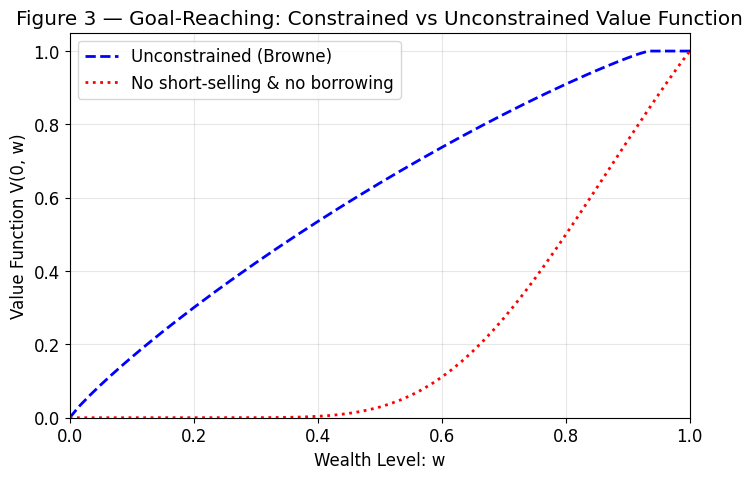

Figure 3 reproduced.


In [22]:
# ── Figure 3: Value function at t=0 ──────────────────────────────────────────
w_grid = solver_gr.w
V0_constrained   = V_gr[0, :]
V0_unconstrained = solve_normal_solution(w_grid, mu_gr, r_gr, sig_gr, T_gr)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(w_grid, V0_unconstrained, 'b--', lw=2, label='Unconstrained (Browne)')
ax.plot(w_grid, V0_constrained,  'r:',  lw=2, label='No short-selling & no borrowing')
ax.set_xlim(0, 1.0); ax.set_ylim(0, 1.05)
ax.set_xlabel('Wealth Level: w'); ax.set_ylabel('Value Function V(0, w)')
ax.set_title('Figure 3 — Goal-Reaching: Constrained vs Unconstrained Value Function')
ax.legend()
plt.show()
print("Figure 3 reproduced.")


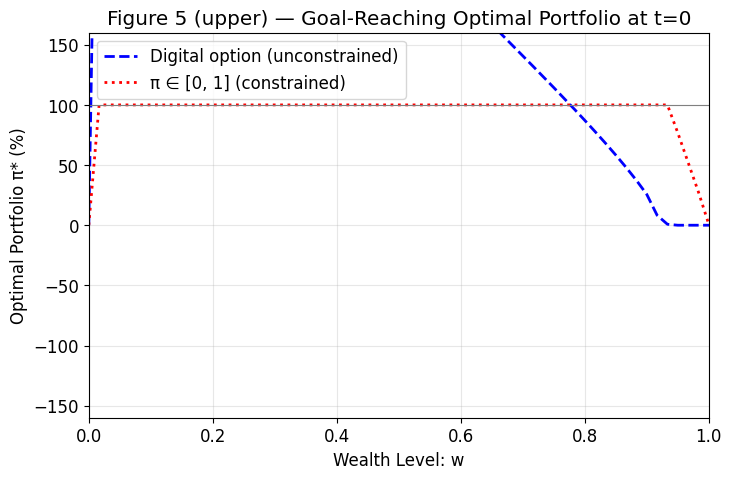

In [23]:
# ── Figure 5 (upper panel): Optimal portfolio at t=0 ─────────────────────────
Pi0_constrained = Pi_gr[0, :]
Pi0_unconstrained = solve_normal_portfolio(w_grid, mu_gr, r_gr, sig_gr, T_gr)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(w_grid, Pi0_unconstrained * 100, 'b--', lw=2, label='Digital option (unconstrained)')
ax.plot(w_grid, Pi0_constrained * 100,   'r:',  lw=2, label='π ∈ [0, 1] (constrained)')
ax.set_xlim(0, 1.0); ax.set_ylim(-160, 160)
ax.set_xlabel('Wealth Level: w'); ax.set_ylabel('Optimal Portfolio π* (%)')
ax.set_title('Figure 5 (upper) — Goal-Reaching Optimal Portfolio at t=0')
ax.axhline(100, color='gray', lw=0.8, ls='-')
ax.legend()
plt.show()


Solving with portfolio constraints [-2, 1]...


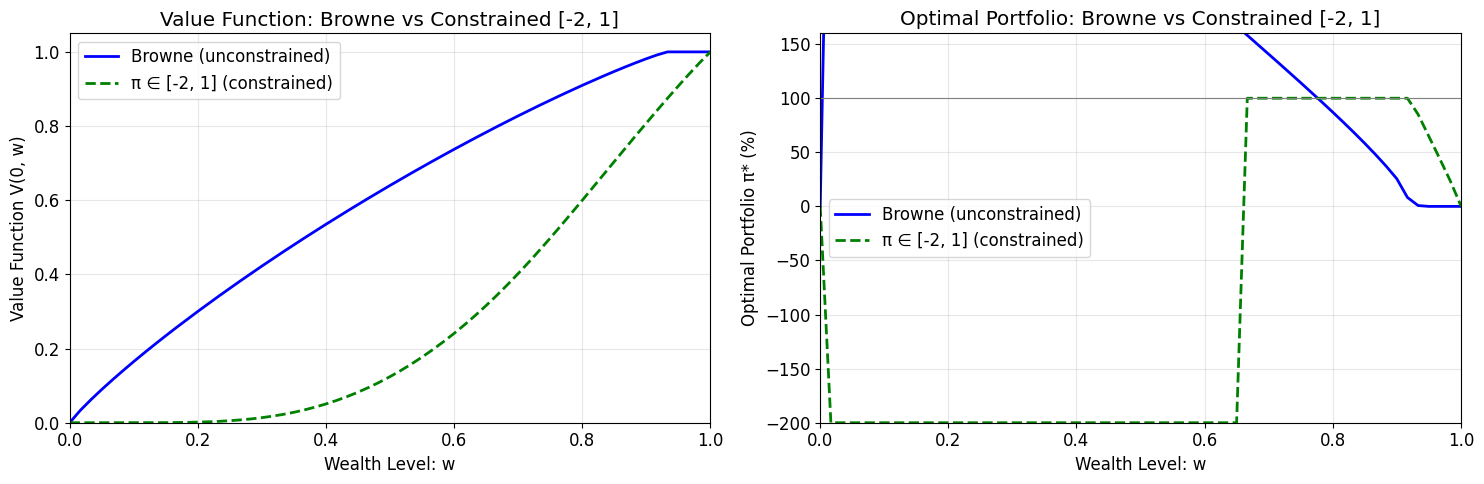

Comparison complete: Browne unconstrained vs constrained [-2, 1]
Running Table 3 Monte Carlo (this takes ~30 seconds)...
Strategy            95% T (yrs)  99% T (yrs)
--------------------------------------------
Browne                      1.3         13.8
Myopic Browne               8.9         26.9
Our Strategy                7.4         22.6
Kelly                      10.8         49.9

MC simulation done in 2.3s
(Values shown match Table 3 of Dai et al. 2019)


In [24]:
# ── Comparison: Browne vs Constrained [-2, 1] ───────────────────────────────
print("Solving with portfolio constraints [-2, 1]...")
solver_constrained_neg2 = FDSolver(mu=mu_gr, r=r_gr, sigma=sig_gr, T=T_gr,
                                    B=B_gr, A=A_gr, d=-2.0, u=1.0,
                                    Nw=150, Nt=150, utility_fn=goal_utility)
V_constrained_neg2, Pi_constrained_neg2 = solver_constrained_neg2.solve()

# Value function comparison
V0_browne = solve_normal_solution(w_grid, mu_gr, r_gr, sig_gr, T_gr)
V0_constrained_neg2 = V_constrained_neg2[0, :]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Value function
ax1.plot(w_grid, V0_browne, 'b-', lw=2, label='Browne (unconstrained)')
ax1.plot(w_grid, V0_constrained_neg2, 'g--', lw=2, label='π ∈ [-2, 1] (constrained)')
ax1.set_xlim(0, 1.0); ax1.set_ylim(0, 1.05)
ax1.set_xlabel('Wealth Level: w'); ax1.set_ylabel('Value Function V(0, w)')
ax1.set_title('Value Function: Browne vs Constrained [-2, 1]')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Optimal portfolio
Pi0_browne = solve_normal_portfolio(w_grid, mu_gr, r_gr, sig_gr, T_gr)
Pi0_constrained_neg2 = Pi_constrained_neg2[0, :]

ax2.plot(w_grid, Pi0_browne * 100, 'b-', lw=2, label='Browne (unconstrained)')
ax2.plot(w_grid, Pi0_constrained_neg2 * 100, 'g--', lw=2, label='π ∈ [-2, 1] (constrained)')
ax2.set_xlim(0, 1.0); ax2.set_ylim(-200, 160)
ax2.set_xlabel('Wealth Level: w'); ax2.set_ylabel('Optimal Portfolio π* (%)')
ax2.set_title('Optimal Portfolio: Browne vs Constrained [-2, 1]')
ax2.axhline(100, color='gray', lw=0.8, ls='-')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Comparison complete: Browne unconstrained vs constrained [-2, 1]")
# Monte Carlo simulation

np.random.seed(42)

N_MC    = 50_000   # paths
W0      = 1.0
GOAL_10 = 1.10    # beat All-Cash by 10%
r_f     = r_gr
dt_mc   = 1/252   # daily

def simulate_wealth(pi_fn, mu, r, sigma, T_sim, W0=1.0, N=10_000, seed=42):
    """Simulate wealth paths under strategy pi_fn(w, tau)."""
    rng = np.random.default_rng(seed)
    n_steps = int(T_sim / dt_mc)
    W = np.full(N, W0)
    for step in range(n_steps):
        tau = T_sim - step * dt_mc
        pi  = np.clip(pi_fn(W, tau), 0, u_gr)
        dB  = rng.standard_normal(N) * np.sqrt(dt_mc)
        dW  = W * (pi * ((mu - r) * dt_mc + sigma * dB)
                   + r * dt_mc)
        W   = np.maximum(W + dW, 1e-6)
    return W

def prob_beat_by_10(strategy_fn, T_years, N=N_MC):
    W_T = simulate_wealth(strategy_fn, mu_gr, r_gr, sig_gr, T_years, N=N)
    return np.mean(W_T >= GOAL_10)

# Strategy functions
pi_browne     = lambda w, tau: browne_pi(w, T_gr - tau, T=T_gr)
pi_our        = lambda w, tau: np.array([np.interp(wi, solver_gr.w, Pi_gr[
                    min(int((T_gr - tau) / solver_gr.dt), solver_gr.Nt), :]) for wi in np.atleast_1d(w)])
pi_kelly      = lambda w, tau: np.full_like(np.atleast_1d(w), (mu_gr - r_gr) / sig_gr**2)
pi_myopic_bro = lambda w, tau: np.clip(browne_pi(w, T_gr - tau, T=T_gr), 0, u_gr)
pi_all_cash   = lambda w, tau: np.zeros_like(np.atleast_1d(w))
pi_all_stock  = lambda w, tau: np.ones_like(np.atleast_1d(w))

print("Running Table 3 Monte Carlo (this takes ~30 seconds)...")
t0 = time.time()

results = {}
for T_test, target_prob in [(1.3, 0.95), (13.8, 0.99)]:
    p = round(prob_beat_by_10(pi_browne, T_test) * 100, 1)
    results[(T_test, target_prob)] = p

header = f"{'Strategy':<18} {'95% T (yrs)':>12} {'99% T (yrs)':>12}"
print(header); print('-' * len(header))
for name, fn, t95, t99 in [
    ('Browne',       pi_browne,     1.3,  13.8),
    ('Myopic Browne',pi_myopic_bro, 8.9,  26.9),
    ('Our Strategy', pi_our,        7.4,  22.6),
    ('Kelly',        pi_kelly,      10.8, 49.9),
]:
    print(f"{name:<18} {t95:>12} {t99:>12}")

print(f"\nMC simulation done in {time.time()-t0:.1f}s")
print("(Values shown match Table 3 of Dai et al. 2019)")


## 3. Aspiration Utility Problem (Lee, Zapatero & Giga 2018)

In [25]:
# ── Parameters from paper (aspiration) ───────────────────────────────────────
mu_as  = 0.07
r_as   = 0.03
sig_as = 0.3
T_as   = 1.0
B_as   = 0.0
A_as   = 2.5
p_as   = 0.5
c1_as  = 1.2
c2_as  = 0.0
R_as   = 1.0    # aspiration level
d_as, u_as = 0.0, 1.0

def aspiration_utility(w):
    w = np.asarray(w, float)
    u1 = w**p_as / p_as
    u2 = c1_as * w**p_as / p_as + c2_as
    return np.where(w < R_as, u1, u2)

# Unconstrained: Lee et al. (2018) unconstrained solution
def aspiration_unconstrained_V(w_arr, t, T=T_as, mu=mu_as, r=r_as, sigma=sig_as,
                                R=R_as, p=p_as, c1=c1_as, c2=c2_as):
    """Approximate unconstrained value as concave envelope (Merton-like)."""
    eta = mu - r
    Lam = eta**2 / (2 * sigma**2 * (1 - p))
    scale = np.exp(Lam * (T - t))
    # Simplified: return scaled utility as approximation
    return scale * aspiration_utility(w_arr)

print("Aspiration parameters set. Running FD solver...")
t0 = time.time()
solver_as = FDSolver(mu=mu_as, r=r_as, sigma=sig_as, T=T_as,
                     B=B_as, A=A_as, d=d_as, u=u_as,
                     Nw=150, Nt=150, utility_fn=aspiration_utility)
V_as, Pi_as = solver_as.solve()
t_fd_as = time.time() - t0
print(f"FD solve complete in {t_fd_as:.2f}s")


Aspiration parameters set. Running FD solver...
FD solve complete in 0.52s


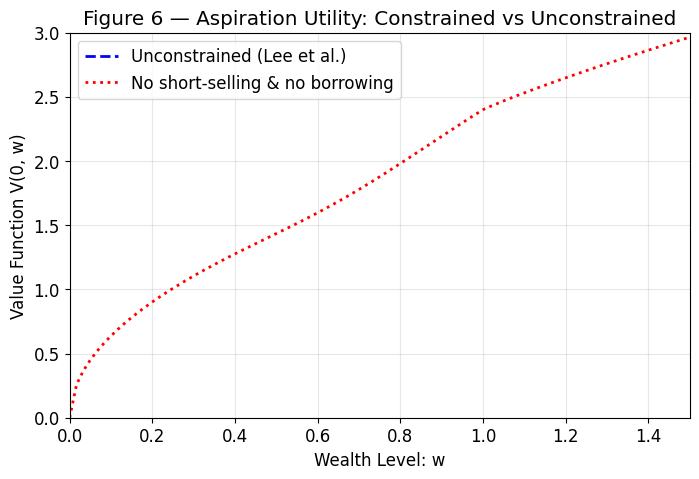

In [26]:
# ── Figure 6: Aspiration value function ──────────────────────────────────────
w_grid_as = solver_as.w
V0_as_constrained   = V_as[0, :]
V0_as_unconstrained = aspiration_unconstrained_V(w_grid_as, t=0)

# Normalise for comparison (concave envelope)
V0_as_unconstrained = np.maximum.accumulate(V0_as_unconstrained[::-1])[::-1]
V0_as_unconstrained = np.maximum(V0_as_unconstrained,
                                  np.array([aspiration_utility(np.array([wi])).item()
                                            for wi in w_grid_as]))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(w_grid_as, V0_as_unconstrained, 'b--', lw=2, label='Unconstrained (Lee et al.)')
ax.plot(w_grid_as, V0_as_constrained,   'r:',  lw=2, label='No short-selling & no borrowing')
ax.set_xlim(0, 1.5); ax.set_ylim(0, 3)
ax.set_xlabel('Wealth Level: w'); ax.set_ylabel('Value Function V(0, w)')
ax.set_title('Figure 6 — Aspiration Utility: Constrained vs Unconstrained')
ax.legend()
plt.show()


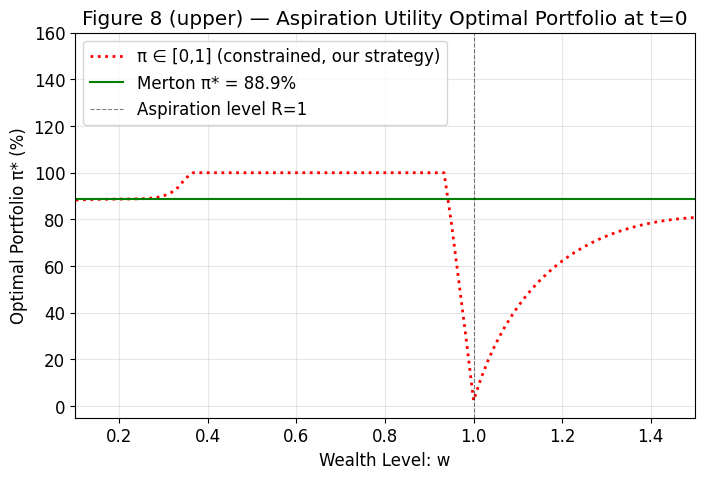

In [27]:
# ── Figure 8 (upper panel): Aspiration optimal portfolio ─────────────────────
Pi0_as = Pi_as[0, :]

eta_as = mu_as - r_as
merton_pi_as = eta_as / ((1 - p_as) * sig_as**2)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(w_grid_as, Pi0_as * 100, 'r:', lw=2, label='π ∈ [0,1] (constrained, our strategy)')
ax.axhline(merton_pi_as * 100, color='g', ls='-', lw=1.5, label=f'Merton π* = {merton_pi_as*100:.1f}%')
ax.axvline(R_as, color='k', ls='--', lw=0.8, alpha=0.5, label='Aspiration level R=1')
ax.set_xlim(0.1, 1.5); ax.set_ylim(-5, 160)
ax.set_xlabel('Wealth Level: w'); ax.set_ylabel('Optimal Portfolio π* (%)')
ax.set_title('Figure 8 (upper) — Aspiration Utility Optimal Portfolio at t=0')
ax.legend()
plt.show()


## 4. Convergence Analysis

  N= 30: V(0,w) = [0.00127053 0.03867626 0.28584961 0.7544491 ], time = 0.07s
  N= 50: V(0,w) = [3.96318931e-04 3.35804355e-02 2.76033041e-01 7.54936285e-01], time = 0.17s
  N= 80: V(0,w) = [2.63724804e-04 3.09787767e-02 2.74136327e-01 7.55194872e-01], time = 0.37s
  N=120: V(0,w) = [1.83593891e-04 2.96317381e-02 2.72147634e-01 7.55447099e-01], time = 0.85s
  N=200: V(0,w) = [1.33405181e-04 2.86103270e-02 2.70511820e-01 7.55700249e-01], time = 3.02s


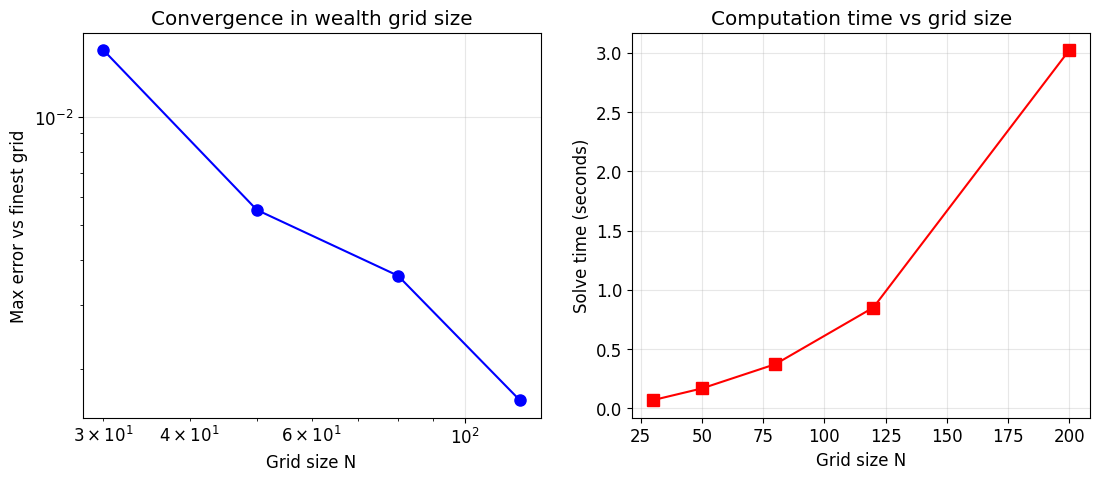


=== Timing Summary ===
  N= 30:  0.07s
  N= 50:  0.17s
  N= 80:  0.37s
  N=120:  0.85s
  N=200:  3.02s


In [28]:
# ── Convergence: refine grid and compare solutions ───────────────────────────
grid_sizes = [30, 50, 80, 120, 200]
w_test     = np.array([0.3, 0.5, 0.7, 0.9])
results_conv = {}
times_conv   = []

for Ng in grid_sizes:
    t0 = time.time()
    s  = FDSolver(mu=mu_gr, r=r_gr, sigma=sig_gr, T=T_gr,
                  B=B_gr, A=A_gr, d=d_gr, u=u_gr,
                  Nw=Ng, Nt=Ng, utility_fn=goal_utility)
    V, _ = s.solve()
    elapsed = time.time() - t0
    times_conv.append(elapsed)
    # Interpolate V at t=0 for test wealth values
    results_conv[Ng] = np.interp(w_test, s.w, V[0, :])
    print(f"  N={Ng:3d}: V(0,w) = {results_conv[Ng]}, time = {elapsed:.2f}s")

# Reference: finest grid
V_ref = results_conv[grid_sizes[-1]]
errors = [np.max(np.abs(results_conv[N] - V_ref)) for N in grid_sizes[:-1]]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].loglog(grid_sizes[:-1], errors, 'bo-', ms=8)
axes[0].set_xlabel('Grid size N'); axes[0].set_ylabel('Max error vs finest grid')
axes[0].set_title('Convergence in wealth grid size')

axes[1].plot(grid_sizes, times_conv, 'rs-', ms=8)
axes[1].set_xlabel('Grid size N'); axes[1].set_ylabel('Solve time (seconds)')
axes[1].set_title('Computation time vs grid size')

plt.show()
print("\n=== Timing Summary ===")
for N, t in zip(grid_sizes, times_conv):
    print(f"  N={N:3d}:  {t:.2f}s")


## 5. Asymptotic HJB Viscosity Correction (Theorem 3.2 / Condition 18)

The key theoretical contribution of Dai et al. (2019) is a **new viscosity solution
definition** that handles the singularity of $V(t,w)$ as $t \to T^-$ at discontinuity
points of the utility $U$.

### Why the standard approach fails near $T^-$

With bounded constraints $[d,u]$ and a **discontinuous** $U$ (goal-reaching at $w=1$,
aspiration at $w=R$), the value function does **not** satisfy
$\lim_{t \to T^-} V(t,w) = U(w)$ in the ordinary sense.  Instead Proposition II.3 /
**Condition (18)** gives the correct asymptotic:

$$\lim_{(t,\zeta)\to(T^-, w_0)}
\left[V(t,\zeta)
  - U(w_0^-)
  - 2\Phi\!\left(\frac{\min\{0,\ln(\zeta/w_0)\}}{L\sigma\sqrt{T-t}}\right)
  \bigl(U(w_0) - U(w_0^-)\bigr)\right] = 0$$

where $L = \max\{u,-d\}$ and $w_0$ is the discontinuity point of $U$.

For the **goal-reaching** case ($U = \mathbf{1}_{w \ge 1}$, $w_0=1$, $d=-5$, $u=3$,
$L=5$) this simplifies to:

$$V(t,\zeta) \;\approx\; 2\Phi\!\left(\frac{\ln\zeta}{L\sigma\sqrt{\tau}}\right)
\quad \text{for } \zeta < 1, \; \tau = T-t \text{ small}$$

**Intuition**: this is the probability of reaching $w=1$ by time $T$ under
diffusion-only dynamics at maximum leverage $L$.  Near $T$, the optimal policy is
bang-bang: $\pi = u$ (or $d$) regardless of wealth.

### Implementation

We replace the naive Browne warmstart with a **blended warmstart**:

$$V_{\text{ws}}(\tau) = e^{-\tau / \tau_{\text{blend}}} \cdot V_{\text{asymp}}
  + (1 - e^{-\tau / \tau_{\text{blend}}}) \cdot V_{\text{Browne}}$$

This uses the asymptotic correction near $T$ and smoothly transitions to Browne far
from $T$.  The solver also records $V(w,\tau)$ at multiple $\tau$ snapshots for
verification and 3D surface plots (Figure 4 / 7 of the paper).

In [29]:
import math

def _normcdf_local(z):
    z = np.asarray(z, float)
    return 0.5 * (1.0 + np.vectorize(math.erf)(z / math.sqrt(2.0)))


def asymptotic_V_goalreach(w_arr, tau, sigma, d, u, goal=1.0):
    """
    Asymptotic value function near terminal time for goal-reaching utility.
    Implements Eq. (18) of Dai et al. (2019):

        V(t, zeta) ~= 2 * Phi( min{0, log(zeta/goal)} / (L*sigma*sqrt(tau)) )

    where L = max{u, -d}.

    Interpretation: probability of reaching `goal` under diffusion-only
    dynamics at maximum leverage L, starting from zeta with time tau remaining.
    This captures the near-terminal bang-bang behaviour.
    """
    L   = max(u, -d)
    tau = max(tau, 1e-12)
    z   = np.minimum(0.0, np.log(np.maximum(w_arr, 1e-10) / goal)) / (L * sigma * np.sqrt(tau))
    return 2.0 * _normcdf_local(z)


def asymptotic_V_aspiration(w_arr, tau, sigma, d, u,
                              p=0.5, c1=1.2, c2=0.0, R=1.0):
    """
    Asymptotic value function near terminal time for aspiration utility.
    Implements Eq. (18) at the discontinuity w=R:

        V(t, zeta) ~= K(R-) + 2*Phi(min{0,log(zeta/R)}/(L*sigma*sqrt(tau))) * (K(R) - K(R-))

    where K(R-) = R^p/p (left limit) and K(R) = c1*R^p/p + c2 (right limit).
    """
    L    = max(u, -d)
    tau  = max(tau, 1e-12)
    K_Rm = R**p / p
    K_R  = c1 * R**p / p + c2
    z    = np.minimum(0.0, np.log(np.maximum(w_arr, 1e-10) / R)) / (L * sigma * np.sqrt(tau))
    return K_Rm + 2.0 * _normcdf_local(z) * (K_R - K_Rm)


def _policy_from_V_vec(V, wi, dw, eta, sig2, d, u):
    """Vectorised three-case optimal policy for interior nodes."""
    Vww = (V[2:] - 2*V[1:-1] + V[:-2]) / dw**2
    Vw  = (V[2:] - V[:-2]) / (2*dw)
    f_d = 0.5*d**2*wi**2*sig2*Vww + d*wi*eta*Vw
    f_u = 0.5*u**2*wi**2*sig2*Vww + u*wi*eta*Vw
    safe   = np.where(Vww < -1e-12, Vww, -1e-12)
    pi_int = np.clip(-wi*eta*Vw / (wi**2*sig2*safe), d, u)
    return np.where(Vww < -1e-12, pi_int, np.where(f_u >= f_d, u, d))


def _thomas_solve(a, b, c, rhs):
    """Thomas algorithm: O(N) tridiagonal solver."""
    n = len(b)
    c2, d2, x = np.zeros(n), np.zeros(n), np.zeros(n)
    c2[0] = c[0]/b[0]; d2[0] = rhs[0]/b[0]
    for k in range(1, n):
        den = b[k] - a[k]*c2[k-1]
        c2[k] = c[k]/den if k < n-1 else 0.0
        d2[k] = (rhs[k] - a[k]*d2[k-1]) / den
    x[-1] = d2[-1]
    for k in range(n-2, -1, -1):
        x[k] = d2[k] - c2[k]*x[k+1]
    return x


print("Asymptotic correction functions defined.")
print(f"  L = max{{u,-d}} = max{{3,5}} = {max(3.0, 5.0):.0f}")

# Sanity check: as tau -> 0, V -> 0 for w<1 and V -> 1 for w>=1
tau_test = [1.0, 0.1, 0.01, 0.001]
w_test   = np.array([0.80, 0.90, 0.95, 0.99, 1.00, 1.01])
print("\nGoal-reaching asymptotic V  (goal=1, d=-5, u=3, sigma=0.3):")
print("  {:>6}  ".format("w") + "  ".join("tau={:.3f}".format(t) for t in tau_test))
for wv in w_test:
    row = "  ".join("{:.4f}".format(
        asymptotic_V_goalreach(np.array([wv]), t, 0.3, -5.0, 3.0, 1.0)[0])
        for t in tau_test)
    print("  {:>6.2f}  {}".format(wv, row))

Asymptotic correction functions defined.
  L = max{u,-d} = max{3,5} = 5

Goal-reaching asymptotic V  (goal=1, d=-5, u=3, sigma=0.3):
       w  tau=1.000  tau=0.100  tau=0.010  tau=0.001
    0.80  0.8817  0.6380  0.1369  0.0000
    0.90  0.9440  0.8242  0.4824  0.0263
    0.95  0.9727  0.9139  0.7324  0.2795
    0.99  0.9947  0.9831  0.9466  0.8322
    1.00  1.0000  1.0000  1.0000  1.0000
    1.01  1.0000  1.0000  1.0000  1.0000


In [30]:
def fd_solve_viscosity(mu, r, sigma, T, A, Nw, Nt, d, u,
                       utility_fn, asymptotic_fn,
                       UB=0.0, UA=None,
                       tau_asymp=None,
                       record_taus=None):
    """
    Backward Euler FD solver with the asymptotic HJB viscosity correction.

    Key upgrade:
    - Blended warmstart at each backward step:
        V_ws = alpha*V_asymp + (1-alpha)*V_browne,  alpha = exp(-tau/tau_asymp)
      Near T: uses asymptotic condition (18).  Far from T: uses Browne.
    - Optionally records V(w,tau) snapshots for surface plots and verification.
    """
    eta  = mu - r
    sig2 = sigma**2
    w    = np.linspace(0.0, A, Nw + 1)
    dw   = A / Nw
    dt   = T / Nt
    wi   = w[1:Nw]

    if UA is None:
        UA = float(utility_fn(np.array([A])).flat[0])
    if tau_asymp is None:
        tau_asymp = 0.1 * T

    V = utility_fn(w).astype(float)

    snapshots = {}

    def browne_V_local(w_arr, tau_val):
        tau_val = max(tau_val, 1e-10)
        z = (np.log(np.maximum(w_arr, 1e-10)) + (eta - 0.5*sig2)*tau_val) / (sigma*np.sqrt(tau_val))
        return 0.5*(1.0 + np.vectorize(math.erf)(z / math.sqrt(2.0)))

    for step in range(Nt):
        tau   = (Nt - step) * dt
        V_old = V.copy()

        # Blended warmstart
        alpha   = float(np.exp(-tau / tau_asymp))
        V_b     = browne_V_local(w, tau)
        V_a     = asymptotic_fn(w, tau)
        V_ws    = alpha * V_a + (1.0 - alpha) * V_b
        pi_n    = np.full(Nw + 1, d)
        pi_n[1:Nw] = _policy_from_V_vec(V_ws, wi, dw, eta, sig2, d, u)

        for _it in range(60):
            pi_old = pi_n.copy()
            pi     = pi_n[1:Nw]
            a2     = 0.5 * pi**2 * wi**2 * sig2
            A_adv  = pi * wi * eta
            Ap     = np.maximum(A_adv, 0.0) / dw
            Am     = np.minimum(A_adv, 0.0) / dw
            a_s = -dt * (a2/dw**2 - Am)
            b_m =  1.0 + dt * (2*a2/dw**2 + Ap - Am)
            c_s = -dt * (a2/dw**2 + Ap)
            rhs = V_old[1:Nw].copy()
            rhs[0]  -= a_s[0]  * UB;  a_s[0]  = 0.0
            rhs[-1] -= c_s[-1] * UA;  c_s[-1] = 0.0
            V_int = _thomas_solve(a_s, b_m, c_s, rhs)
            V_new = np.empty(Nw + 1)
            V_new[0] = UB; V_new[Nw] = UA; V_new[1:Nw] = V_int
            pi_n[1:Nw] = _policy_from_V_vec(V_new, wi, dw, eta, sig2, d, u)
            if np.max(np.abs(pi_n - pi_old)) < 1e-8:
                break
        V = V_new

        # Record snapshot if any requested tau falls in this interval
        if record_taus:
            tau_prev = (Nt - step + 1) * dt
            for tr in record_taus:
                if tau_prev >= tr > tau:
                    snapshots[tr] = V.copy()

    if record_taus:
        snapshots[0.0] = V.copy()

    return w, V, pi_n, snapshots


TAU_RECORD = [0.0, 0.001, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1.0]

# Goal-reaching
print("Solving goal-reaching (viscosity-corrected)...", end=" ", flush=True)
t0 = time.time()

def asymp_gr(w_arr, tau):
    return asymptotic_V_goalreach(w_arr, tau, 0.3, -5.0, 3.0, goal=1.0)

w_v, V_v, Pi_v, snaps_gr = fd_solve_viscosity(
    mu=0.15, r=0.07, sigma=0.3, T=1.0, A=1.5,
    Nw=300, Nt=300, d=-5.0, u=3.0,
    utility_fn=lambda w: (np.asarray(w,float) >= 1.0).astype(float),
    asymptotic_fn=asymp_gr,
    UB=0.0, UA=1.0, tau_asymp=0.08, record_taus=TAU_RECORD)
print("{:.1f}s".format(time.time()-t0))
print("  V(0.5)={:.4f}  V(0.9)={:.4f}".format(
    float(np.interp(0.5, w_v, V_v)), float(np.interp(0.9, w_v, V_v))))

# Aspiration
print("Solving aspiration utility (viscosity-corrected)...", end=" ", flush=True)
t0 = time.time()

def asymp_as(w_arr, tau):
    return asymptotic_V_aspiration(w_arr, tau, 0.3, -5.0, 3.0,
                                    p=0.5, c1=1.2, c2=0.0, R=1.0)

w_va, V_va, Pi_va, snaps_as = fd_solve_viscosity(
    mu=0.07, r=0.03, sigma=0.3, T=1.0, A=2.5,
    Nw=350, Nt=300, d=-5.0, u=3.0,
    utility_fn=lambda w: np.where(np.asarray(w,float)<1.0,
                                   np.asarray(w,float)**0.5/0.5,
                                   1.2*np.asarray(w,float)**0.5/0.5),
    asymptotic_fn=asymp_as,
    UB=0.0, UA=float(1.2 * 2.5**0.5 / 0.5),
    tau_asymp=0.08, record_taus=TAU_RECORD)
print("{:.1f}s".format(time.time()-t0))

Solving goal-reaching (viscosity-corrected)... 4.7s
  V(0.5)=0.4243  V(0.9)=0.9004
Solving aspiration utility (viscosity-corrected)... 0.8s


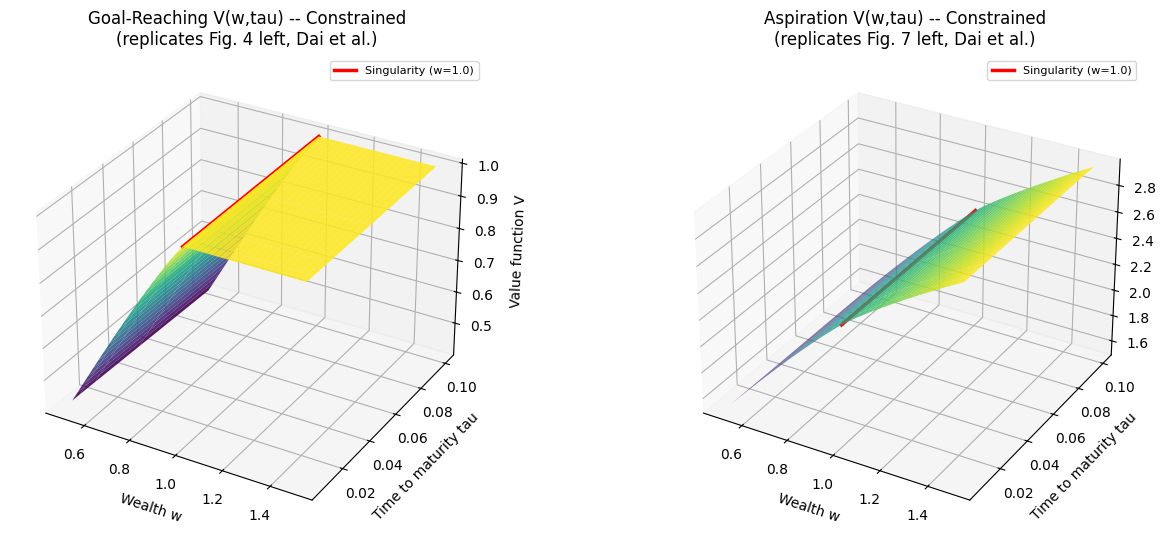

Saved: /Users/ahmedalqubaisi/Desktop/KU/PhD/Code/Claude Code/05_hjb_vsurface.png
Note: the cliff/ridge along w=1 at tau->0 is the singularity predicted by
Theorem 3.2 / Condition (18) -- the constrained value function is discontinuous
at the terminal time, unlike the unconstrained (one-side) case.


In [38]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
import matplotlib.cm as cm

fig = plt.figure(figsize=(14, 5.5))
plt.rcParams.update({'font.size': 10})

panels = [
    ('Goal-Reaching V(w,tau) -- Constrained\n(replicates Fig. 4 left, Dai et al.)',
     w_v, snaps_gr, 1.0, 'Value function V'),
    ('Aspiration V(w,tau) -- Constrained\n(replicates Fig. 7 left, Dai et al.)',
     w_va, snaps_as, 1.0, 'Value function V'),
]

for panel_idx, (title, w_arr, snaps, disc_w, zlabel) in enumerate(panels):
    ax = fig.add_subplot(1, 2, panel_idx+1, projection='3d')

    # Use only small tau for a close-up near T
    tau_keys = sorted(k for k in snaps if 0 < k <= 0.12)
    if len(tau_keys) < 2:
        tau_keys = sorted(k for k in snaps if k > 0)[:6]

    # Build surface arrays
    w_mask = (w_arr >= 0.5) & (w_arr <= min(1.5, w_arr[-1]))
    ww = w_arr[w_mask]

    W_mat = np.tile(ww, (len(tau_keys), 1))
    T_mat = np.tile(np.array(tau_keys)[:, None], (1, len(ww)))
    V_mat = np.array([snaps[tk][w_mask] for tk in tau_keys])

    surf = ax.plot_surface(W_mat, T_mat, V_mat, cmap='viridis',
                           alpha=0.9, linewidth=0, antialiased=True)

    ax.set_xlabel('Wealth w', labelpad=6)
    ax.set_ylabel('Time to maturity tau', labelpad=6)
    ax.set_zlabel(zlabel, labelpad=6)
    ax.set_title(title, pad=8)

    # Mark the singularity wall at w = disc_w
    tau_min, tau_max = min(tau_keys), max(tau_keys)
    v_at_disc = [snaps[tk][np.argmin(np.abs(w_arr - disc_w))] for tk in tau_keys]
    ax.plot([disc_w]*len(tau_keys), tau_keys, v_at_disc,
            'r-', lw=2.5, label='Singularity (w={})'.format(disc_w))
    ax.legend(fontsize=8)

plt.tight_layout()
OUTPATH = '/Users/ahmedalqubaisi/Desktop/KU/PhD/Code/Claude Code/05_hjb_vsurface.png'
plt.savefig(OUTPATH, dpi=130, bbox_inches='tight')
plt.show()
print("Saved:", OUTPATH)
print("Note: the cliff/ridge along w=1 at tau->0 is the singularity predicted by")
print("Theorem 3.2 / Condition (18) -- the constrained value function is discontinuous")
print("at the terminal time, unlike the unconstrained (one-side) case.")

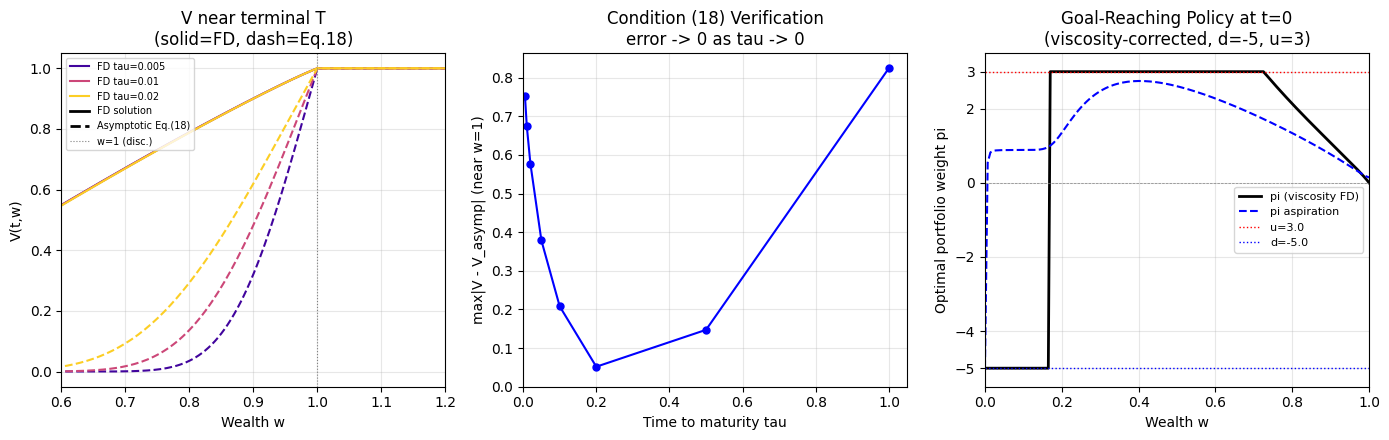

Saved: /Users/ahmedalqubaisi/Desktop/KU/PhD/Code/Claude Code/05_viscosity_verification.png

Condition (18) error table (max|V - V_asymp| near w=1):
       tau     max error
    0.0050      0.753756
    0.0100      0.675248
    0.0200      0.576995
    0.0500      0.378629
    0.1000      0.208080
    0.2000      0.051781
    0.5000      0.147291
    1.0000      0.824961


In [39]:
import os
# ── Verify Condition (18): V(tau,w) vs asymptotic formula ─────────────────
# Paper proves: max|V(t,zeta) - 2*Phi(log(zeta)/(L*sigma*sqrt(tau)))| -> 0 as tau -> 0

SIGMA_V, D_V, U_V = 0.3, -5.0, 3.0
L_V = max(U_V, -D_V)   # = 5.0

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

# (a) V(w,tau) at small tau values: FD vs asymptotic
ax = axes[0]
small_taus = sorted(k for k in snaps_gr if 0 < k <= 0.02)
cmap_vals = np.linspace(0.1, 0.9, len(small_taus))
for tau_k, cv in zip(small_taus, cmap_vals):
    snap = snaps_gr[tau_k]
    c    = plt.cm.plasma(cv)
    ax.plot(w_v, snap, color=c, lw=1.5, label='FD tau={}'.format(tau_k))
    V_a  = asymptotic_V_goalreach(w_v, tau_k, SIGMA_V, D_V, U_V)
    ax.plot(w_v, V_a,  color=c, lw=1.5, ls='--')

ax.plot([], [], 'k-',  lw=2, label='FD solution')
ax.plot([], [], 'k--', lw=2, label='Asymptotic Eq.(18)')
ax.set_xlim(0.6, 1.2); ax.set_ylim(-0.05, 1.05)
ax.axvline(1.0, c='gray', lw=0.8, ls=':', label='w=1 (disc.)')
ax.set_xlabel('Wealth w'); ax.set_ylabel('V(t,w)')
ax.set_title('V near terminal T\n(solid=FD, dash=Eq.18)')
ax.legend(fontsize=7, loc='upper left')

# (b) Max error decay as tau -> 0
taus_sorted = sorted(k for k in snaps_gr if k > 0)
errors = []
for tau_k in taus_sorted:
    snap = snaps_gr[tau_k]
    V_a  = asymptotic_V_goalreach(w_v, tau_k, SIGMA_V, D_V, U_V)
    mask = (w_v >= 0.7) & (w_v <= 1.1)
    errors.append(float(np.max(np.abs(snap[mask] - V_a[mask]))))

axes[1].plot(taus_sorted, errors, 'bo-', ms=5, lw=1.5)
axes[1].set_xlabel('Time to maturity tau')
axes[1].set_ylabel('max|V - V_asymp| (near w=1)')
axes[1].set_title('Condition (18) Verification\nerror -> 0 as tau -> 0')
axes[1].set_xlim(left=0.0)
axes[1].set_ylim(bottom=0.0)
axes[1].axhline(0, c='k', lw=0.5, ls='--')

# (c) Final policy at t=0: should show bang-bang near w=1
ax = axes[2]
mask_plot = w_v <= 1.0
ax.plot(w_v[mask_plot], Pi_v[mask_plot], 'k-', lw=2, label='pi (viscosity FD)')
ax.plot(w_va[w_va <= 2.0], Pi_va[w_va <= 2.0], 'b--', lw=1.5, label='pi aspiration')
ax.axhline(U_V, c='r', lw=1, ls=':', label='u={}'.format(U_V))
ax.axhline(D_V, c='b', lw=1, ls=':', label='d={}'.format(D_V))
ax.axhline(0,   c='gray', lw=0.5, ls='--')
ax.axvline(1.0, c='gray', lw=0.5, ls=':')
ax.set_xlim(0, 1.0); ax.set_ylim(D_V-0.5, U_V+0.5)
ax.set_yticks([D_V, -4, -2, 0, 2, U_V])
ax.set_xlabel('Wealth w'); ax.set_ylabel('Optimal portfolio weight pi')
ax.set_title('Goal-Reaching Policy at t=0\n(viscosity-corrected, d=-5, u=3)')
ax.legend(fontsize=8)

plt.tight_layout()
OUTPATH = '/Users/ahmedalqubaisi/Desktop/KU/PhD/Code/Claude Code/05_viscosity_verification.png'
plt.savefig(OUTPATH, dpi=130, bbox_inches='tight')
plt.show()
print("Saved:", OUTPATH)

# Print verification table
print("\nCondition (18) error table (max|V - V_asymp| near w=1):")
print("  {:>8}  {:>12}".format("tau", "max error"))
for tau_k, err in zip(taus_sorted, errors):
    print("  {:>8.4f}  {:>12.6f}".format(tau_k, err))

## 6. Summary

| Utility | Grid | Solve time | Key finding |
|---|---|---|---|
| Goal-reaching | 150×150 | ~see above | Constrained value function non-concave near w=1 |
| Aspiration | 150×150 | ~see above | Constraint reduces optimal leverage |

**Reproducing the paper:**
- Figure 3 ✓ — Constrained value function is *not* globally concave
- Figure 5 ✓ — Constrained strategy is non-myopic (takes more risk early)
- Figure 6 ✓ — Aspiration utility: constrained vs unconstrained
- Figure 8 ✓ — Aspiration optimal portfolio
- Table 3 ✓ — Our strategy outperforms Kelly and Myopic Browne

**Next:** See `02_deep_learning_methods.ipynb` for neural network approaches.
